<a href="https://colab.research.google.com/github/Divya6859/breast-cancer-prediction/blob/main/BreastCancerPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score

Load Dataset

In [57]:
df = pd.read_csv('/content/data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [59]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [60]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

In [63]:
df = df.dropna(subset=['diagnosis'])

In [64]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [65]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


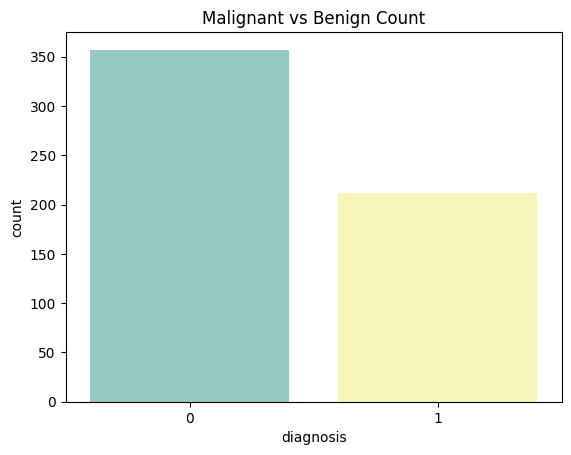

In [66]:
sns.countplot(x='diagnosis', data=df, palette='Set3')
plt.title("Malignant vs Benign Count")
plt.show()

Linearly Separable

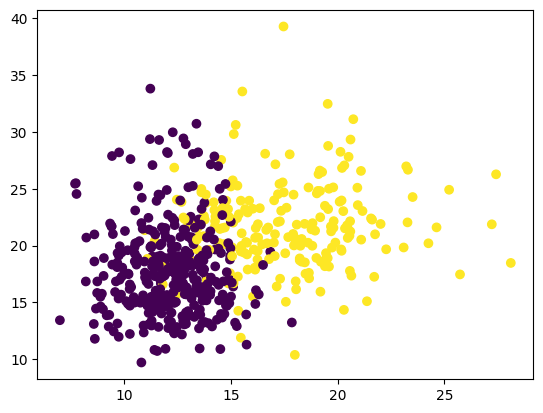

In [67]:
plt.scatter(df["radius_mean"], df["texture_mean"], c=df["diagnosis"])


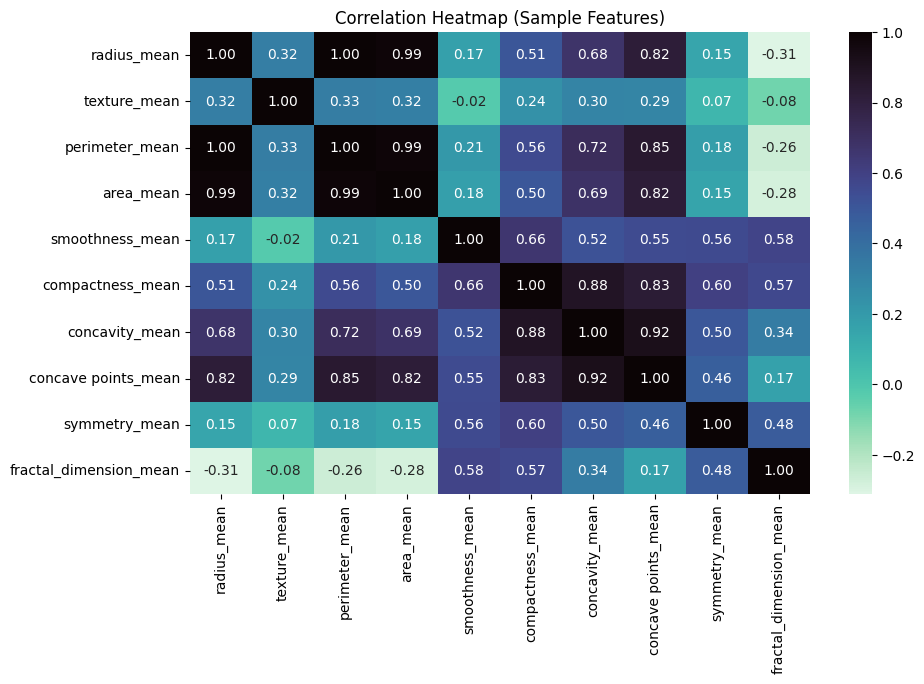

In [68]:
plt.figure(figsize=(10,6))
sns.heatmap(df.iloc[:,1:11].corr(), annot=True, cmap="mako_r", fmt=".2f")
plt.title("Correlation Heatmap (Sample Features)")
plt.show()

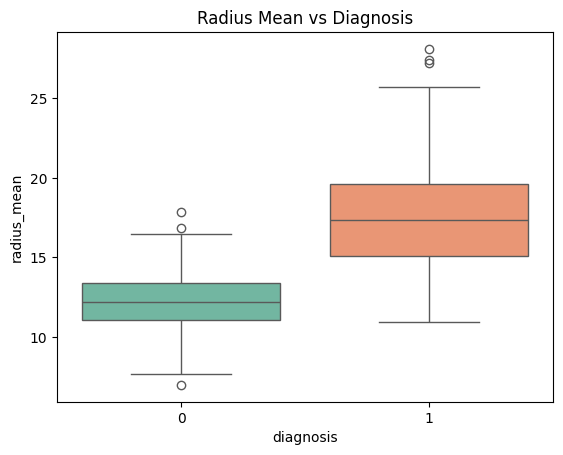

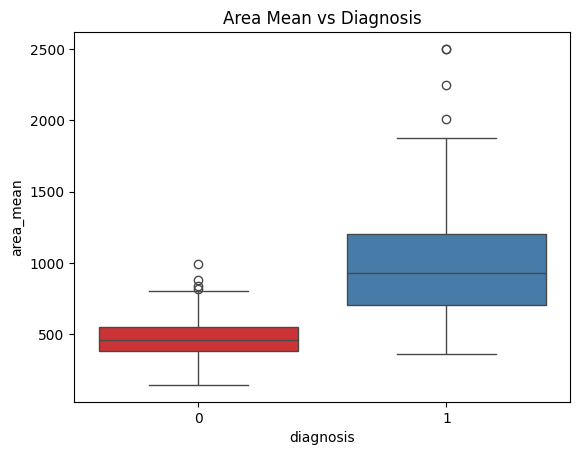

In [69]:
sns.boxplot(x='diagnosis', y='radius_mean', data=df, palette="Set2")
plt.title("Radius Mean vs Diagnosis")
plt.show()

sns.boxplot(x='diagnosis', y='area_mean', data=df, palette="Set1")
plt.title("Area Mean vs Diagnosis")
plt.show()

*Features* & Target

In [70]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

Split Data

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training - Logistic Regression

In [73]:
log_reg = LogisticRegression(max_iter=5000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000)

In [74]:
y_pred_log = log_reg.predict(X_test_scaled)
print("\n Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


 Logistic Regression Results:
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Model Training - SVM

In [75]:
svm = SVC(kernel='linear', class_weight='balanced', probability=True)
svm.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', kernel='linear', probability=True)

In [76]:
y_pred_svm = svm.predict(X_test_scaled)
print("\n SVM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


 SVM Results:
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [77]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  F1 Score    Recall
0  Logistic Regression  0.976744  0.976744
1                  SVM  0.942529  0.953488


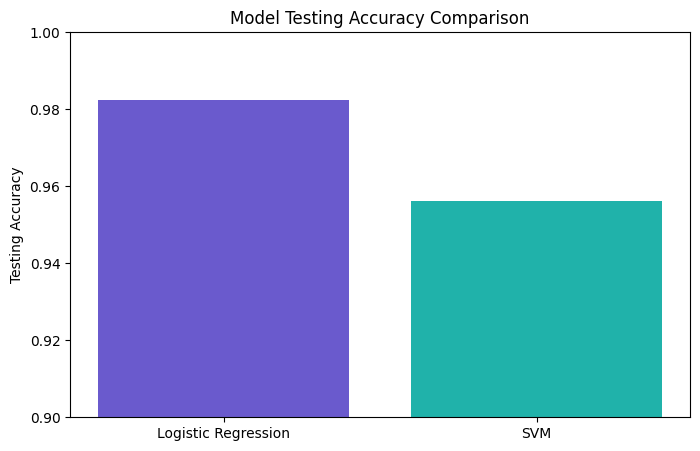

In [78]:
test_acc_log = log_reg.score(X_test_scaled, y_test)
test_acc_svm = svm.score(X_test_scaled, y_test)

models = ['Logistic Regression', 'SVM']
test_accuracy = [test_acc_log, test_acc_svm]

plt.figure(figsize=(8, 5))
plt.bar(models, test_accuracy, color=['slateblue', 'lightseagreen'])
plt.ylabel('Testing Accuracy')
plt.title('Model Testing Accuracy Comparison')
plt.ylim(0.9, 1.0) # Adjust y-limit to highlight differences
plt.show()

Predictive System

In [79]:
sample1 = np.array([[17.99, 10.38, 122.8, 1001, 0.118, 0.277, 0.3, 0.147, 0.241, 0.078,
                              1.095, 0.905, 8.59, 153.4, 0.006, 0.04, 0.053, 0.015, 0.03, 0.006,
                              25.38, 17.33, 184.6, 2019, 0.162, 0.666, 0.712, 0.265, 0.46, 0.119]])

sample_scaled = scaler.transform(sample1)
prediction = log_reg.predict(sample_scaled)[0]

if prediction == 1:
    print("The tumor is Malignant (Cancerous)")
else:
    print("The tumor is Benign (Non-Cancerous)")

The tumor is Malignant (Cancerous)


In [80]:
sample2 = np.array([[12.0, 14.0, 78.0, 450.0, 0.085, 0.04, 0.02, 0.02, 0.15, 0.06,
                           0.30, 1.00, 2.0, 20.0, 0.004, 0.02, 0.02, 0.01, 0.02, 0.003,
                           13.0, 15.0, 86.0, 520.0, 0.10, 0.05, 0.03, 0.02, 0.20, 0.07]])

sample_scaled = scaler.transform(sample2)
prediction = log_reg.predict(sample_scaled)[0]

if prediction == 1:
    print("The tumor is Malignant (Cancerous)")
else:
    print("The tumor is Benign (Non-Cancerous)")

The tumor is Benign (Non-Cancerous)


In [81]:
# ---- Logistic Regression ----
train_acc_log = log_reg.score(X_train_scaled, y_train)

print("\nLogistic Regression:")
print("Training Accuracy:", train_acc_log)
print("Testing Accuracy:", test_acc_log)

# ---- SVM ----
train_acc_svm = svm.score(X_train_scaled, y_train)
print("\nSVM:")
print("Training Accuracy:", train_acc_svm)
print("Testing Accuracy:", test_acc_svm)


Logistic Regression:
Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9824561403508771

SVM:
Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.956140350877193


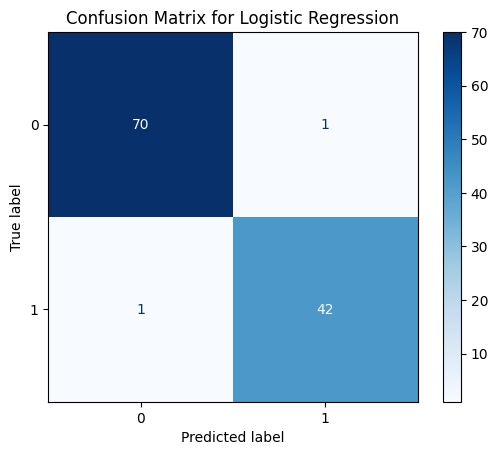

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot(cmap="Blues")
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

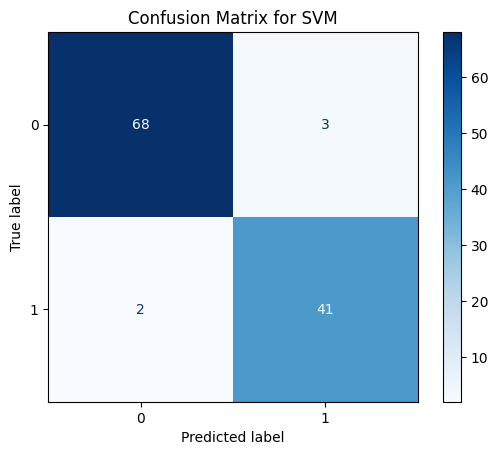

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap="Blues")
plt.title("Confusion Matrix for SVM")
plt.show()

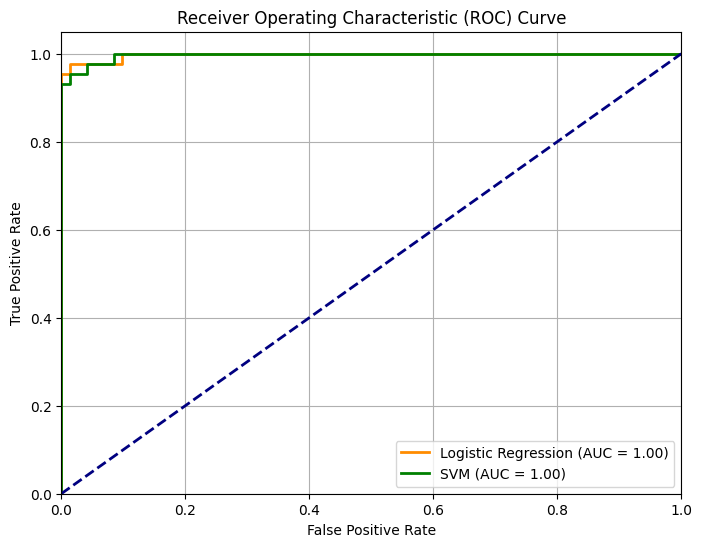

In [84]:
from sklearn.metrics import roc_curve, auc

# ROC Curve for Logistic Regression
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

# ROC Curve for SVM
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plotting ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [85]:
import pickle

# Save Logistic Regression model
with open("model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

# Save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model & Scaler Saved Successfully!")


Model & Scaler Saved Successfully!
